<a href="https://colab.research.google.com/github/rpa0855-ai/insurance-charges-prediction/blob/main/Insurance_Charges_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Insurance Charges Prediction
Regression project on the Medical Cost Personal Dataset (age, sex, bmi, children, smoker, region, charges).

## Load Data

In [1]:
url = 'https://raw.githubusercontent.com/stedy/Machine-Learning-with-R-datasets/master/insurance.csv'
!wget -q -O insurance.csv {url}

In [2]:
!pip install -q catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 6.7 MB/s eta 0:00:00


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from sklearn.model_selection import train_test_split, RandomizedSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.base import clone
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import xgboost as xgb
import shap

import lightgbm as lgb
from catboost import CatBoostRegressor

In [4]:
df = pd.read_csv('insurance.csv')
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [5]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


## Exploratory Data Analysis

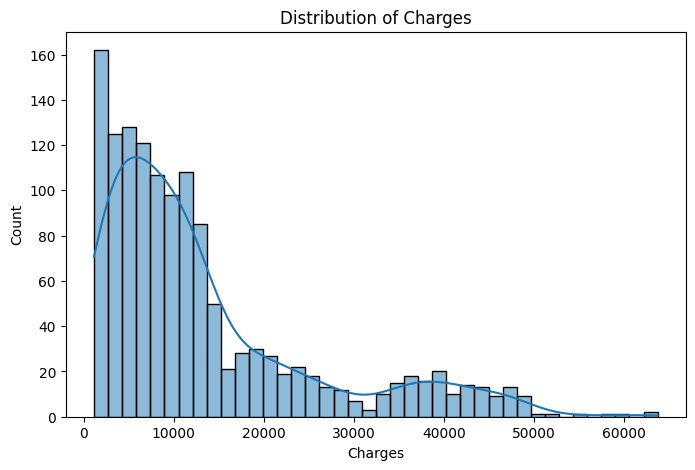

Skewness: 1.5158796580240388


In [6]:
plt.figure(figsize=(8, 5))
sns.histplot(df['charges'], kde=True, bins=40)
plt.title('Distribution of Charges')
plt.xlabel('Charges')
plt.show()

# charges is right-skewed, most people have low charges, few have very high ones
print('Skewness:', df['charges'].skew())

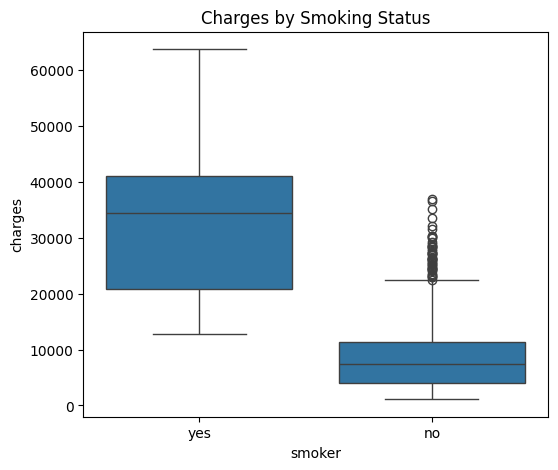

In [7]:
plt.figure(figsize=(6, 5))
sns.boxplot(x='smoker', y='charges', data=df)
plt.title('Charges by Smoking Status')
plt.show()

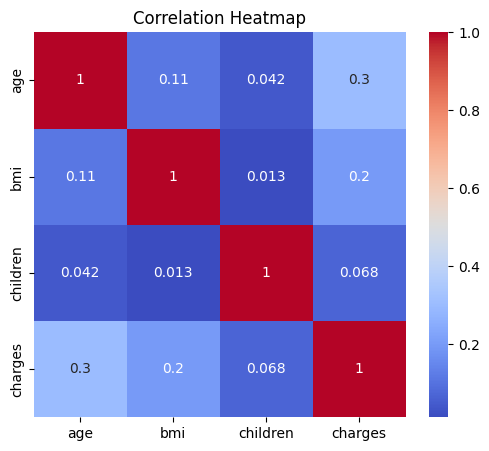

In [8]:
plt.figure(figsize=(6, 5))
numeric_df = df.select_dtypes(include=np.number)
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

## Statistical Tests

In [9]:
# check if charges follows a normal distribution - this affects whether t-test/ANOVA assumptions hold
shapiro_stat, shapiro_p = stats.shapiro(df['charges'])
print(f"Shapiro-Wilk stat: {shapiro_stat:.4f}, p-value: {shapiro_p:.5f}")

if shapiro_p < 0.05:
    print("Charges is not normally distributed - consistent with the right-skew seen in the EDA.")
else:
    print("Charges appears normally distributed.")

Shapiro-Wilk stat: 0.8147, p-value: 0.00000
Charges is not normally distributed - consistent with the right-skew seen in the EDA.


In [10]:
# t-test: do smokers and non-smokers have different average charges?
smoker_charges = df[df['smoker'] == 'yes']['charges']
nonsmoker_charges = df[df['smoker'] == 'no']['charges']

t_stat, p_val = stats.ttest_ind(smoker_charges, nonsmoker_charges, equal_var=False)
print(f"t-statistic: {t_stat:.3f}, p-value: {p_val:.5f}")

t-statistic: 32.752, p-value: 0.00000


In [11]:
# effect size - p-value says the difference is significant, Cohen's d says how large it is
pooled_std = np.sqrt(((len(smoker_charges) - 1) * smoker_charges.std()**2 +
                       (len(nonsmoker_charges) - 1) * nonsmoker_charges.std()**2) /
                      (len(smoker_charges) + len(nonsmoker_charges) - 2))
cohens_d = (smoker_charges.mean() - nonsmoker_charges.mean()) / pooled_std

print(f"Cohen's d: {cohens_d:.3f}")
print("(0.2 = small, 0.5 = medium, 0.8+ = large effect)")

Cohen's d: 3.161
(0.2 = small, 0.5 = medium, 0.8+ = large effect)


In [12]:
# ANOVA: does average charge differ across the 4 regions?
region_groups = [group['charges'].values for name, group in df.groupby('region')]
f_stat, p_val = stats.f_oneway(*region_groups)
print(f"F-statistic: {f_stat:.3f}, p-value: {p_val:.5f}")

F-statistic: 2.970, p-value: 0.03089


In [13]:
age_corr, age_p = stats.pearsonr(df['age'], df['charges'])
bmi_corr, bmi_p = stats.pearsonr(df['bmi'], df['charges'])

print(f"Age vs Charges: r={age_corr:.3f}, p={age_p:.5f}")
print(f"BMI vs Charges: r={bmi_corr:.3f}, p={bmi_p:.5f}")

Age vs Charges: r=0.299, p=0.00000
BMI vs Charges: r=0.198, p=0.00000


In [14]:
# chi-square: are these categorical variables independent of each other?
# (checks for confounding - e.g. are smokers concentrated in one region?)
sex_smoker_table = pd.crosstab(df['sex'], df['smoker'])
chi2_1, p_1, dof_1, expected_1 = stats.chi2_contingency(sex_smoker_table)
print(f"sex vs smoker: chi2={chi2_1:.3f}, p={p_1:.5f}")

smoker_region_table = pd.crosstab(df['smoker'], df['region'])
chi2_2, p_2, dof_2, expected_2 = stats.chi2_contingency(smoker_region_table)
print(f"smoker vs region: chi2={chi2_2:.3f}, p={p_2:.5f}")

sex vs smoker: chi2=7.393, p=0.00655
smoker vs region: chi2=7.343, p=0.06172


## Feature Engineering

In [15]:
bins = [0, 18.5, 25, 30, np.inf]
labels = ['underweight', 'normal', 'overweight', 'obese']
df['bmi_category'] = pd.cut(df['bmi'], bins=bins, labels=labels)
df[['bmi', 'bmi_category']].head()

,bmi,bmi_category
0,27.900,overweight
1,33.770,obese
2,33.000,obese
3,22.705,normal
4,28.880,overweight


In [16]:
# interaction feature - smoking combined with high bmi tends to push charges up a lot more
# than either factor alone, so give the model this signal directly
df['smoker_bmi'] = df['bmi'] * (df['smoker'] == 'yes').astype(int)
df[['smoker', 'bmi', 'smoker_bmi']].head()

,smoker,bmi,smoker_bmi
0,yes,27.900,27.9
1,no,33.770,0.0
2,no,33.000,0.0
3,no,22.705,0.0
4,no,28.880,0.0


## Multicollinearity Check (VIF)

In [17]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools import add_constant

# check if the numeric predictors are too correlated with each other to trust individually
# add_constant is required here - without it, VIF values come out artificially inflated
vif_features = add_constant(df[['age', 'bmi', 'children', 'smoker_bmi']])
vif_df = pd.DataFrame()
vif_df['feature'] = vif_features.columns
vif_df['VIF'] = [variance_inflation_factor(vif_features.values, i) for i in range(vif_features.shape[1])]
vif_df = vif_df[vif_df['feature'] != 'const'].reset_index(drop=True)
vif_df

,feature,VIF
0,age,1.014782
1,bmi,1.024867
2,children,1.001912
3,smoker_bmi,1.012955


## Outlier & Influential Point Detection (Hat Matrix & Cook's Distance)

In [18]:
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import OLSInfluence

# simple linear fit on the numeric predictors, just to get leverage and influence diagnostics
X_diag = add_constant(df[['age', 'bmi', 'children', 'smoker_bmi']])
y_diag = df['charges']

ols_model = sm.OLS(y_diag, X_diag).fit()
influence = OLSInfluence(ols_model)

leverage = influence.hat_matrix_diag
cooks_d = influence.cooks_distance[0]

print(f"Mean leverage: {leverage.mean():.5f}")
print(f"High-leverage points (> 2x mean): {(leverage > 2 * leverage.mean()).sum()}")
print(f"High-influence points (Cook's D > 4/n): {(cooks_d > 4 / len(df)).sum()}")

Mean leverage: 0.00374
High-leverage points (> 2x mean): 63
High-influence points (Cook's D > 4/n): 85


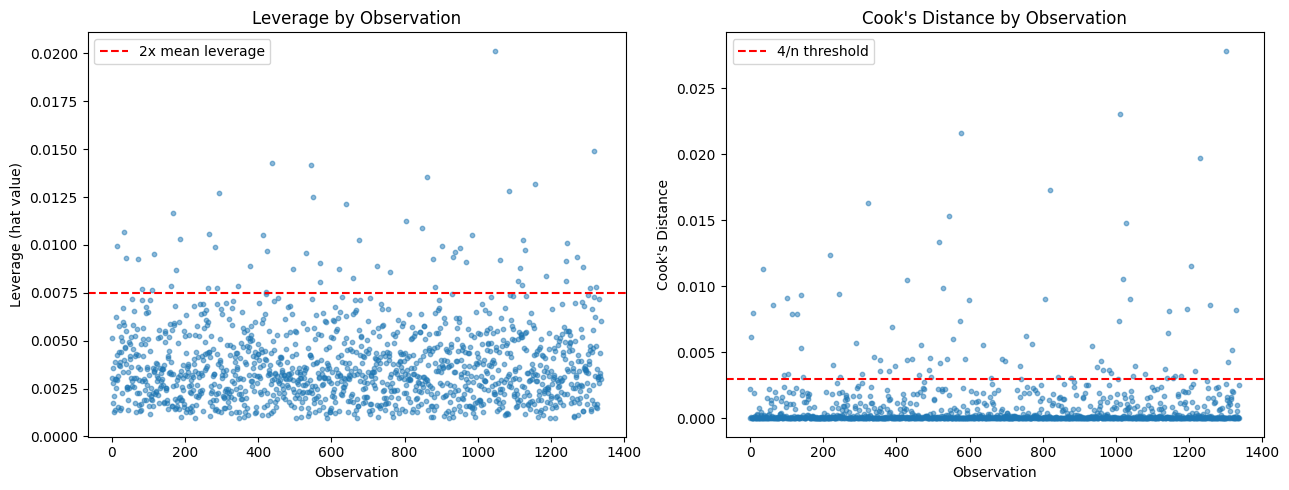

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].scatter(range(len(leverage)), leverage, alpha=0.5, s=10)
axes[0].axhline(y=2 * leverage.mean(), color='r', linestyle='--', label='2x mean leverage')
axes[0].set_xlabel('Observation')
axes[0].set_ylabel('Leverage (hat value)')
axes[0].set_title('Leverage by Observation')
axes[0].legend()

axes[1].scatter(range(len(cooks_d)), cooks_d, alpha=0.5, s=10)
axes[1].axhline(y=4 / len(df), color='r', linestyle='--', label="4/n threshold")
axes[1].set_xlabel('Observation')
axes[1].set_ylabel("Cook's Distance")
axes[1].set_title("Cook's Distance by Observation")
axes[1].legend()

plt.tight_layout()
plt.show()

## Preprocessing

In [20]:
X = df.drop(columns='charges')
y = df['charges']

numeric_cols = ['age', 'bmi', 'children', 'smoker_bmi']
categorical_cols = ['sex', 'smoker', 'region', 'bmi_category']

preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(), numeric_cols),
    ('cat', OneHotEncoder(drop='first', sparse_output=False), categorical_cols)
])

In [21]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## Model Selection Among Linear Models (AIC, BIC, Mallows' Cp)

In [22]:
# AIC/BIC/Cp only make sense for likelihood-based linear models, so this compares
# Linear/Ridge/Lasso against each other, separately from the wider model comparison below
prep_for_aic = clone(preprocessor)
X_train_transformed = prep_for_aic.fit_transform(X_train)

X_sm = add_constant(X_train_transformed)
ols_full = sm.OLS(y_train.values, X_sm).fit()

n = len(y_train)
p = X_sm.shape[1] - 1
mse_full = np.sum(ols_full.resid ** 2) / n

print(f"Full linear model - AIC: {ols_full.aic:.1f}, BIC: {ols_full.bic:.1f}")

Full linear model - AIC: 21196.4, BIC: 21261.1


In [23]:
def mallows_cp(residuals, mse_full_model, n_obs, k_params):
    rss = np.sum(residuals ** 2)
    return rss / mse_full_model - (n_obs - 2 * k_params)

aic_bic_results = []
for name, model in [('LinearRegression', LinearRegression()), ('Ridge', Ridge(alpha=1.0)), ('Lasso', Lasso(alpha=0.001))]:
    model.fit(X_train_transformed, y_train)
    preds = model.predict(X_train_transformed)
    resid = y_train.values - preds
    rss = np.sum(resid ** 2)
    k = np.sum(np.abs(model.coef_) > 1e-6) + 1
    aic = n * np.log(rss / n) + 2 * k
    bic = n * np.log(rss / n) + k * np.log(n)
    cp = mallows_cp(resid, mse_full, n, k)
    aic_bic_results.append([name, round(aic, 1), round(bic, 1), round(cp, 1)])

aic_bic_df = pd.DataFrame(aic_bic_results, columns=['Model', 'AIC', 'BIC', "Mallows' Cp"])
aic_bic_df.sort_values(by='AIC').reset_index(drop=True)

,Model,AIC,BIC,Mallows' Cp
0,LinearRegression,18159.8,18224.5,26.0
1,Lasso,18159.8,18224.5,26.0
2,Ridge,18163.8,18228.4,29.9


## Model Comparison

In [24]:
model_defs = {
    "LinearRegression": LinearRegression(),
    "Ridge": Ridge(alpha=1.0),
    "Lasso": Lasso(alpha=0.001),
    "RandomForest": RandomForestRegressor(n_estimators=200, random_state=42),
    "GradientBoosting": GradientBoostingRegressor(n_estimators=200, random_state=42),
    "XGBoost": xgb.XGBRegressor(n_estimators=200, learning_rate=0.1, max_depth=4, random_state=42),
    "LightGBM": lgb.LGBMRegressor(n_estimators=200, learning_rate=0.1, max_depth=4, random_state=42, verbose=-1),
    "CatBoost": CatBoostRegressor(n_estimators=200, learning_rate=0.1, max_depth=4, random_state=42, verbose=0)
}

results = []
fitted_pipes = {}

for name, model in model_defs.items():
    pipe = Pipeline(steps=[('preprocessor', preprocessor), ('model', model)])
    pipe.fit(X_train, y_train)
    preds = pipe.predict(X_test)

    mae = mean_absolute_error(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    r2 = r2_score(y_test, preds)

    results.append([name, mae, rmse, r2])
    fitted_pipes[name] = pipe

results_df = pd.DataFrame(results, columns=['Model', 'MAE', 'RMSE', 'R2'])
results_df = results_df.sort_values(by='R2', ascending=False).reset_index(drop=True)
results_df

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


,Model,MAE,RMSE,R2
0,CatBoost,2359.760309,4222.233687,0.885170
1,GradientBoosting,2545.783633,4479.171041,0.870769
2,LightGBM,2586.677032,4518.901518,0.868466
3,Ridge,2725.956802,4529.714255,0.867836
4,Lasso,2698.827142,4539.344747,0.867273
5,LinearRegression,2698.825270,4539.346942,0.867273
6,XGBoost,2582.935384,4577.476703,0.865034
7,RandomForest,2567.019914,4577.900088,0.865009


In [25]:
best_model_name = results_df.loc[0, 'Model']
best_r2 = results_df.loc[0, 'R2']
best_pipe = fitted_pipes[best_model_name]

print(f"Best model: {best_model_name}, R2 = {best_r2:.3f}")

Best model: CatBoost, R2 = 0.885


In [26]:
# Adjusted R2 penalizes R2 for the number of predictors used, unlike plain R2
n_test = len(y_test)
p_test = best_pipe.named_steps['preprocessor'].transform(X_test).shape[1]
untuned_r2 = best_r2
untuned_adj_r2 = 1 - (1 - untuned_r2) * (n_test - 1) / (n_test - p_test - 1)

print(f"Untuned R2: {untuned_r2:.3f}")
print(f"Untuned Adjusted R2: {untuned_adj_r2:.3f}")

Untuned R2: 0.885
Untuned Adjusted R2: 0.880


## Baseline Comparison

In [27]:
from sklearn.dummy import DummyRegressor

# sanity check - how much better is the best model than just guessing the average charge?
dummy_pipe = Pipeline(steps=[('preprocessor', preprocessor), ('model', DummyRegressor(strategy='mean'))])
dummy_pipe.fit(X_train, y_train)
dummy_preds = dummy_pipe.predict(X_test)

dummy_r2 = r2_score(y_test, dummy_preds)
dummy_mae = mean_absolute_error(y_test, dummy_preds)

print(f"Baseline (mean prediction) R2: {dummy_r2:.3f}, MAE: {dummy_mae:.2f}")
print(f"Best model ({best_model_name}) R2: {best_r2:.3f}")
print(f"Improvement over baseline: {best_r2 - dummy_r2:.3f} R2")

Baseline (mean prediction) R2: -0.001, MAE: 9593.34
Best model (CatBoost) R2: 0.885
Improvement over baseline: 0.886 R2


## Log-Transform Check

In [28]:
# retrain the best model on log1p(charges) and see if it helps with the skew
log_model = clone(model_defs[best_model_name])
log_pipe = Pipeline(steps=[('preprocessor', preprocessor), ('model', log_model)])

log_pipe.fit(X_train, np.log1p(y_train))
log_preds = np.expm1(log_pipe.predict(X_test))

log_r2 = r2_score(y_test, log_preds)

print(f"R2 without log transform: {best_r2:.3f}")
print(f"R2 with log transform: {log_r2:.3f}")

R2 without log transform: 0.885
R2 with log transform: 0.877


## Hyperparameter Tuning - Setup

In [29]:
tuning_pipe = Pipeline(steps=[('preprocessor', preprocessor), ('model', clone(model_defs[best_model_name]))])

if best_model_name == "RandomForest":
    param_dist = {
        "model__n_estimators": [100, 200, 300, 400],
        "model__max_depth": [None, 5, 10, 15, 20]
    }
elif best_model_name == "GradientBoosting":
    param_dist = {
        "model__n_estimators": [100, 200, 300],
        "model__max_depth": [2, 3, 4, 5],
        "model__learning_rate": [0.01, 0.05, 0.1, 0.2]
    }
elif best_model_name == "XGBoost":
    param_dist = {
        "model__n_estimators": [100, 200, 300],
        "model__max_depth": [3, 4, 5, 6],
        "model__learning_rate": [0.01, 0.05, 0.1, 0.2]
    }
elif best_model_name == "LightGBM":
    param_dist = {
        "model__n_estimators": [100, 200, 300],
        "model__max_depth": [3, 4, 5, 6],
        "model__learning_rate": [0.01, 0.05, 0.1, 0.2]
    }
elif best_model_name == "CatBoost":
    param_dist = {
        "model__n_estimators": [100, 200, 300],
        "model__max_depth": [3, 4, 5, 6],
        "model__learning_rate": [0.01, 0.05, 0.1, 0.2]
    }
else:
    param_dist = None

# keep a record of every tuning method's result here, starting with the untuned baseline
tuning_results = [["Baseline (no tuning)", best_r2, results_df.loc[0, 'MAE'], results_df.loc[0, 'RMSE'], best_pipe]]

if param_dist is None:
    print(f"{best_model_name} has no tree hyperparameters to tune, skipping all tuning methods.")

## Method 1: RandomizedSearchCV

In [30]:
if param_dist is not None:
    random_search = RandomizedSearchCV(tuning_pipe, param_dist, n_iter=15, cv=5,
                                        scoring='r2', random_state=42, n_jobs=-1)
    random_search.fit(X_train, y_train)
    random_preds = random_search.predict(X_test)

    random_r2 = r2_score(y_test, random_preds)
    random_mae = mean_absolute_error(y_test, random_preds)
    random_rmse = np.sqrt(mean_squared_error(y_test, random_preds))

    print(f"RandomizedSearch R2: {random_r2:.3f}")
    print("Best params:", random_search.best_params_)

    tuning_results.append(["RandomizedSearch", random_r2, random_mae, random_rmse, random_search.best_estimator_])

RandomizedSearch R2: 0.880
Best params: {'model__n_estimators': 100, 'model__max_depth': 3, 'model__learning_rate': 0.05}


## Method 2: GridSearchCV (fine grid around RandomizedSearch result)

In [31]:
from sklearn.model_selection import GridSearchCV

if param_dist is not None:
    best_params = random_search.best_params_

    if best_model_name in ("GradientBoosting", "XGBoost"):
        fine_grid = {
            "model__n_estimators": [max(50, best_params["model__n_estimators"] - 50),
                                     best_params["model__n_estimators"],
                                     best_params["model__n_estimators"] + 50],
            "model__max_depth": list({max(2, best_params["model__max_depth"] - 1),
                                       best_params["model__max_depth"],
                                       best_params["model__max_depth"] + 1}),
            "model__learning_rate": list({round(best_params["model__learning_rate"] * 0.5, 4),
                                           best_params["model__learning_rate"],
                                           round(best_params["model__learning_rate"] * 1.5, 4)})
        }
    else:
        fine_grid = {
            "model__n_estimators": [max(50, best_params["model__n_estimators"] - 50),
                                     best_params["model__n_estimators"],
                                     best_params["model__n_estimators"] + 50],
            "model__max_depth": [best_params["model__max_depth"]]
        }

    grid_search = GridSearchCV(tuning_pipe, fine_grid, cv=5, scoring='r2', n_jobs=-1)
    grid_search.fit(X_train, y_train)
    grid_preds = grid_search.predict(X_test)

    grid_r2 = r2_score(y_test, grid_preds)
    grid_mae = mean_absolute_error(y_test, grid_preds)
    grid_rmse = np.sqrt(mean_squared_error(y_test, grid_preds))

    print(f"GridSearch R2: {grid_r2:.3f}")
    print("Best params:", grid_search.best_params_)

    tuning_results.append(["GridSearch", grid_r2, grid_mae, grid_rmse, grid_search.best_estimator_])

GridSearch R2: 0.876
Best params: {'model__max_depth': 3, 'model__n_estimators': 50}


## Method 3: HalvingGridSearchCV

In [32]:
from sklearn.experimental import enable_halving_search_cv
from sklearn.model_selection import HalvingGridSearchCV

if param_dist is not None:
    halving_search = HalvingGridSearchCV(tuning_pipe, param_dist, cv=5, scoring='r2',
                                          factor=2, random_state=42, n_jobs=-1)
    halving_search.fit(X_train, y_train)
    halving_preds = halving_search.predict(X_test)

    halving_r2 = r2_score(y_test, halving_preds)
    halving_mae = mean_absolute_error(y_test, halving_preds)
    halving_rmse = np.sqrt(mean_squared_error(y_test, halving_preds))

    print(f"HalvingGridSearch R2: {halving_r2:.3f}")
    print("Best params:", halving_search.best_params_)

    tuning_results.append(["HalvingGridSearch", halving_r2, halving_mae, halving_rmse, halving_search.best_estimator_])

HalvingGridSearch R2: 0.881
Best params: {'model__learning_rate': 0.05, 'model__max_depth': 4, 'model__n_estimators': 100}


## Method 4: Optuna (Bayesian Optimization)

In [33]:
!pip install -q optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 13.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 265.9/265.9 kB 19.4 MB/s eta 0:00:00


In [34]:
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

def objective(trial):
    if best_model_name == "RandomForest":
        params = {
            "n_estimators": trial.suggest_int("n_estimators", 100, 400),
            "max_depth": trial.suggest_int("max_depth", 3, 20)
        }
    elif best_model_name == "GradientBoosting":
        params = {
            "n_estimators": trial.suggest_int("n_estimators", 100, 300),
            "max_depth": trial.suggest_int("max_depth", 2, 6),
            "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3, log=True)
        }
    elif best_model_name == "XGBoost":
        params = {
            "n_estimators": trial.suggest_int("n_estimators", 100, 300),
            "max_depth": trial.suggest_int("max_depth", 3, 8),
            "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3, log=True)
        }
    elif best_model_name == "LightGBM":
        params = {
            "n_estimators": trial.suggest_int("n_estimators", 100, 300),
            "max_depth": trial.suggest_int("max_depth", 3, 8),
            "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3, log=True)
        }
    elif best_model_name == "CatBoost":
        params = {
            "n_estimators": trial.suggest_int("n_estimators", 100, 300),
            "max_depth": trial.suggest_int("max_depth", 3, 8),
            "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3, log=True)
        }
    else:
        return best_r2

    model = clone(model_defs[best_model_name])
    model.set_params(**params)
    pipe = Pipeline(steps=[('preprocessor', preprocessor), ('model', model)])
    score = cross_val_score(pipe, X_train, y_train, cv=5, scoring='r2', n_jobs=-1).mean()
    return score

if param_dist is not None:
    study = optuna.create_study(direction="maximize")
    study.optimize(objective, n_trials=20, show_progress_bar=False)

    optuna_model = clone(model_defs[best_model_name])
    optuna_model.set_params(**study.best_params)
    optuna_pipe = Pipeline(steps=[('preprocessor', preprocessor), ('model', optuna_model)])
    optuna_pipe.fit(X_train, y_train)
    optuna_preds = optuna_pipe.predict(X_test)

    optuna_r2 = r2_score(y_test, optuna_preds)
    optuna_mae = mean_absolute_error(y_test, optuna_preds)
    optuna_rmse = np.sqrt(mean_squared_error(y_test, optuna_preds))

    print(f"Optuna R2: {optuna_r2:.3f}")
    print("Best params:", study.best_params)

    tuning_results.append(["Optuna", optuna_r2, optuna_mae, optuna_rmse, optuna_pipe])

Optuna R2: 0.879
Best params: {'n_estimators': 260, 'max_depth': 4, 'learning_rate': 0.016863411386593398}


## Tuning Methods Comparison

In [35]:
tuning_df = pd.DataFrame(tuning_results, columns=["Method", "R2", "MAE", "RMSE", "Pipeline"])
tuning_df = tuning_df.sort_values(by="R2", ascending=False).reset_index(drop=True)
print(tuning_df[["Method", "R2", "MAE", "RMSE"]])

best_row = tuning_df.iloc[0]
best_r2 = best_row["R2"]
best_mae = best_row["MAE"]
best_rmse = best_row["RMSE"]
best_pipe = best_row["Pipeline"]

print(f"\nBest tuning method: {best_row['Method']} with R2 = {best_r2:.3f}")

                 Method        R2          MAE         RMSE
0  Baseline (no tuning)  0.885170  2359.760309  4222.233687
1     HalvingGridSearch  0.881087  2443.350296  4296.641437
2      RandomizedSearch  0.879541  2451.626910  4324.483668
3                Optuna  0.879410  2484.924815  4326.834776
4            GridSearch  0.875815  2496.633451  4390.849892

Best tuning method: Baseline (no tuning) with R2 = 0.885


## Ensemble Learning Comparison

In [36]:
from sklearn.ensemble import VotingRegressor, StackingRegressor

# combine all five tree-based models to see if averaging/stacking beats the single best tuned model
tree_estimators = [
    ('gb', clone(model_defs['GradientBoosting'])),
    ('xgb', clone(model_defs['XGBoost'])),
    ('rf', clone(model_defs['RandomForest'])),
    ('lgb', clone(model_defs['LightGBM'])),
    ('cat', clone(model_defs['CatBoost']))
]

voting_model = VotingRegressor(estimators=tree_estimators)
voting_pipe = Pipeline(steps=[('preprocessor', preprocessor), ('model', voting_model)])
voting_pipe.fit(X_train, y_train)
voting_preds = voting_pipe.predict(X_test)

voting_r2 = r2_score(y_test, voting_preds)
voting_mae = mean_absolute_error(y_test, voting_preds)
voting_rmse = np.sqrt(mean_squared_error(y_test, voting_preds))
print(f"VotingRegressor R2: {voting_r2:.3f}")

stacking_model = StackingRegressor(estimators=tree_estimators, final_estimator=Ridge())
stacking_pipe = Pipeline(steps=[('preprocessor', preprocessor), ('model', stacking_model)])
stacking_pipe.fit(X_train, y_train)
stacking_preds = stacking_pipe.predict(X_test)

stacking_r2 = r2_score(y_test, stacking_preds)
stacking_mae = mean_absolute_error(y_test, stacking_preds)
stacking_rmse = np.sqrt(mean_squared_error(y_test, stacking_preds))
print(f"StackingRegressor R2: {stacking_r2:.3f}")

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


VotingRegressor R2: 0.877


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


StackingRegressor R2: 0.886


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


In [37]:
ensemble_results = pd.DataFrame([
    ["Best single tuned model", best_r2, best_mae, best_rmse],
    ["VotingRegressor", voting_r2, voting_mae, voting_rmse],
    ["StackingRegressor", stacking_r2, stacking_mae, stacking_rmse]
], columns=["Method", "R2", "MAE", "RMSE"]).sort_values(by="R2", ascending=False).reset_index(drop=True)

print(ensemble_results)

# only switch the final model if an ensemble genuinely does better
if ensemble_results.loc[0, "Method"] != "Best single tuned model":
    best_r2 = ensemble_results.loc[0, "R2"]
    best_mae = ensemble_results.loc[0, "MAE"]
    best_rmse = ensemble_results.loc[0, "RMSE"]
    best_model_name = ensemble_results.loc[0, "Method"]
    best_pipe = voting_pipe if best_model_name == "VotingRegressor" else stacking_pipe
    print(f"\nEnsemble improved the result, using {best_model_name} as the final model.")
else:
    print("\nSingle tuned model is still the best, keeping it as the final model.")

                    Method        R2          MAE         RMSE
0        StackingRegressor  0.885946  2335.687975  4207.943769
1  Best single tuned model  0.885170  2359.760309  4222.233687
2          VotingRegressor  0.876576  2452.980953  4377.373960

Ensemble improved the result, using StackingRegressor as the final model.


## Feature Importance

In [38]:
best_model_step = best_pipe.named_steps['model']
feature_names = best_pipe.named_steps['preprocessor'].get_feature_names_out()

if hasattr(best_model_step, 'feature_importances_'):
    importances = best_model_step.feature_importances_
    imp_df = pd.DataFrame({'feature': feature_names, 'importance': importances})
    imp_df = imp_df.sort_values(by='importance', ascending=False)

    plt.figure(figsize=(8, 6))
    sns.barplot(x='importance', y='feature', data=imp_df)
    plt.title(f'Feature Importance - {best_model_name}')
    plt.show()
else:
    print(f"{best_model_name} does not expose feature_importances_")

StackingRegressor does not expose feature_importances_


## SHAP Explanation

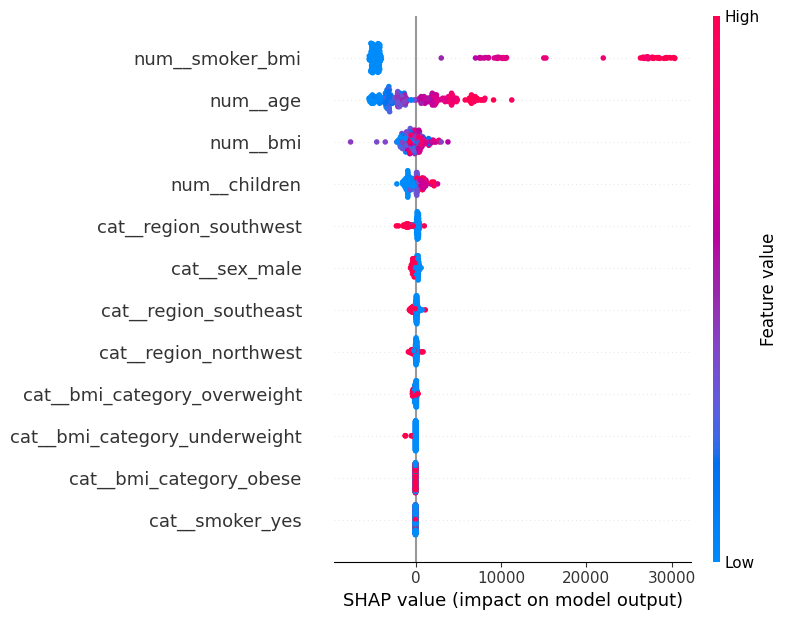

In [39]:
xgb_pipe = fitted_pipes['XGBoost']
X_test_transformed = xgb_pipe.named_steps['preprocessor'].transform(X_test)
shap_feature_names = xgb_pipe.named_steps['preprocessor'].get_feature_names_out()

explainer = shap.TreeExplainer(xgb_pipe.named_steps['model'])
shap_values = explainer.shap_values(X_test_transformed)

shap.summary_plot(shap_values, X_test_transformed, feature_names=shap_feature_names)

## Partial Dependence Plots

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/v

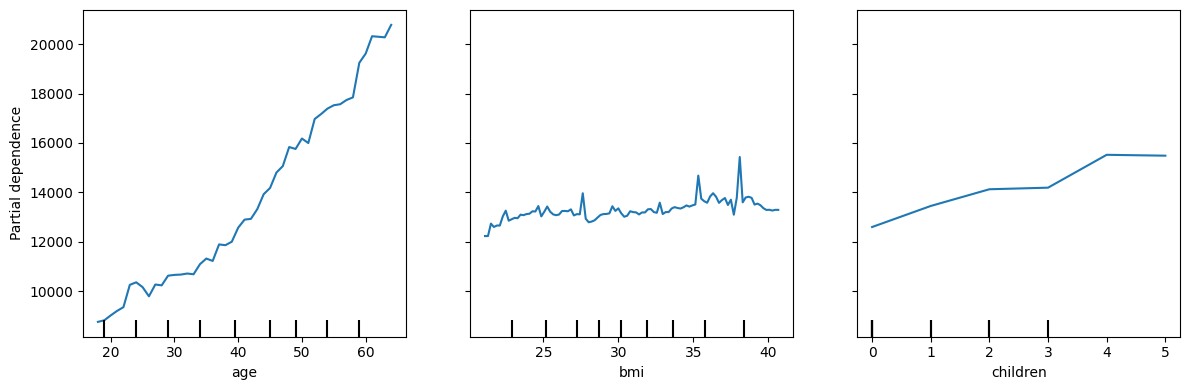

In [40]:
from sklearn.inspection import PartialDependenceDisplay

# shows how the prediction changes as one feature moves, holding the others constant
fig, ax = plt.subplots(figsize=(12, 4))
PartialDependenceDisplay.from_estimator(best_pipe, X_train, features=['age', 'bmi', 'children'], ax=ax)
plt.tight_layout()
plt.show()

## Final Result

In [41]:
n_test = len(y_test)
p_test = best_pipe.named_steps['preprocessor'].transform(X_test).shape[1]
final_adj_r2 = 1 - (1 - best_r2) * (n_test - 1) / (n_test - p_test - 1)

print("Final Model Results")
print(f"Best model: {best_model_name}")
print(f"R2: {best_r2:.3f}")
print(f"Adjusted R2: {final_adj_r2:.3f}")
print(f"Adjusted R2 improved from {untuned_adj_r2:.3f} (untuned) to {final_adj_r2:.3f} (final)")
print(f"MAE: {best_mae:.2f}")
print(f"RMSE: {best_rmse:.2f}")

Final Model Results
Best model: StackingRegressor
R2: 0.886
Adjusted R2: 0.881
Adjusted R2 improved from 0.880 (untuned) to 0.881 (final)
MAE: 2335.69
RMSE: 4207.94


## Cross-Validation Stability Check

In [42]:
# check that the R2 above isn't just a lucky 80/20 split
cv_scores = cross_val_score(best_pipe, X, y, cv=10, scoring='r2')

print("R2 across 10 folds:", np.round(cv_scores, 3))
print(f"Mean R2: {cv_scores.mean():.3f}")
print(f"Std R2: {cv_scores.std():.3f}")

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/v

R2 across 10 folds: [0.893 0.872 0.842 0.76  0.872 0.926 0.881 0.819 0.882 0.859]
Mean R2: 0.861
Std R2: 0.043


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


## Learning Curves

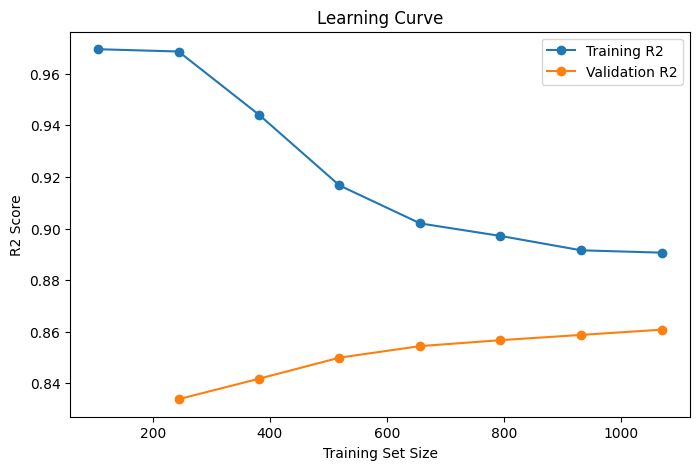

In [43]:
from sklearn.model_selection import learning_curve

# check if the model is underfitting, overfitting, or would benefit from more data
train_sizes, train_scores, val_scores = learning_curve(
    best_pipe, X, y, cv=5, scoring='r2',
    train_sizes=np.linspace(0.1, 1.0, 8), n_jobs=-1
)

train_mean = train_scores.mean(axis=1)
val_mean = val_scores.mean(axis=1)

plt.figure(figsize=(8, 5))
plt.plot(train_sizes, train_mean, 'o-', label='Training R2')
plt.plot(train_sizes, val_mean, 'o-', label='Validation R2')
plt.xlabel('Training Set Size')
plt.ylabel('R2 Score')
plt.title('Learning Curve')
plt.legend()
plt.show()

## Residual Analysis

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


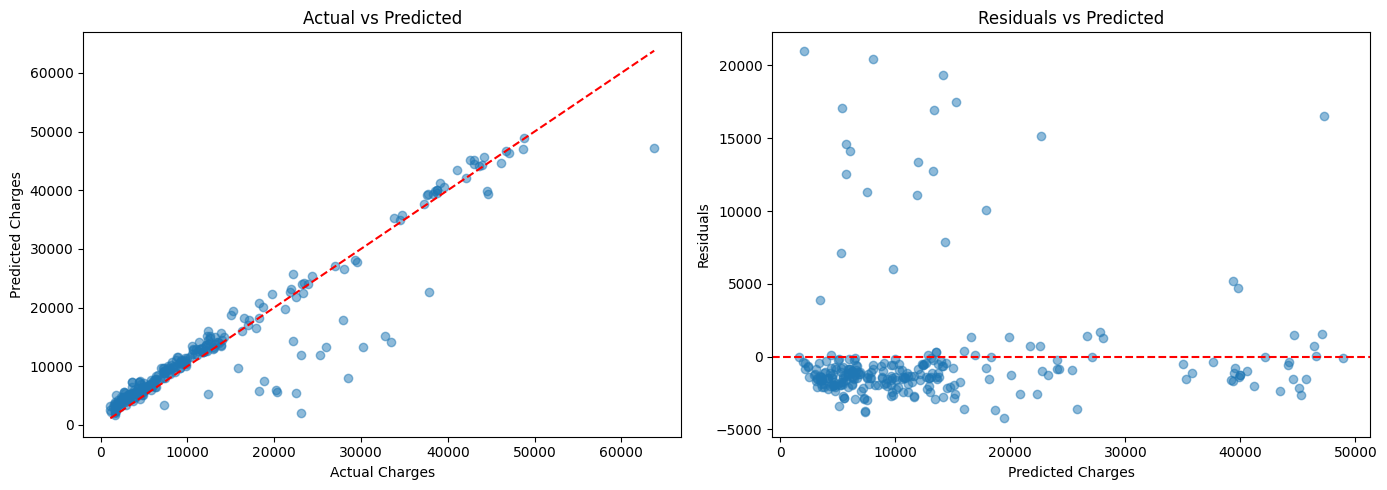

In [44]:
final_preds = best_pipe.predict(X_test)
residuals = y_test - final_preds

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(y_test, final_preds, alpha=0.5)
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
axes[0].set_xlabel('Actual Charges')
axes[0].set_ylabel('Predicted Charges')
axes[0].set_title('Actual vs Predicted')

axes[1].scatter(final_preds, residuals, alpha=0.5)
axes[1].axhline(y=0, color='r', linestyle='--')
axes[1].set_xlabel('Predicted Charges')
axes[1].set_ylabel('Residuals')
axes[1].set_title('Residuals vs Predicted')

plt.tight_layout()
plt.show()

In [45]:
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.tools import add_constant

# formally test what the residuals-vs-predicted plot suggests - is the error variance constant?
X_test_transformed_bp = best_pipe.named_steps['preprocessor'].transform(X_test)
X_test_bp = add_constant(X_test_transformed_bp)

bp_stat, bp_pvalue, _, _ = het_breuschpagan(residuals, X_test_bp)
print(f"Breusch-Pagan stat: {bp_stat:.3f}, p-value: {bp_pvalue:.5f}")

if bp_pvalue < 0.05:
    print("Heteroscedasticity detected - error variance is not constant, larger charges tend to have larger errors.")
else:
    print("No significant heteroscedasticity detected.")

Breusch-Pagan stat: 8.307, p-value: 0.76074
No significant heteroscedasticity detected.


## Durbin-Watson Test (Autocorrelation of Residuals)

In [46]:
from statsmodels.stats.stattools import durbin_watson

# this dataset has no time variable, so this checks residual order-dependence in the
# test set as a standard diagnostic formality, not a genuine time-series check
dw_stat = durbin_watson(residuals)
print(f"Durbin-Watson statistic: {dw_stat:.3f}")
print("(around 2.0 = no autocorrelation, toward 0 = positive autocorrelation, toward 4 = negative autocorrelation)")

Durbin-Watson statistic: 2.130
(around 2.0 = no autocorrelation, toward 0 = positive autocorrelation, toward 4 = negative autocorrelation)


In [47]:
# the cases the model struggles with the most
error_df = pd.DataFrame({'actual': y_test, 'predicted': final_preds, 'abs_error': np.abs(residuals)})
error_df.sort_values(by='abs_error', ascending=False).head(10)

,actual,predicted,abs_error
430,23082.95533,2074.362355,21008.592975
806,28476.73499,8054.913556,20421.821434
599,33471.97189,14134.787717,19337.184173
128,32734.18630,15243.776298,17490.410002
1039,22493.65964,5405.277628,17088.382012
115,30259.99556,13351.489483,16908.506077
543,63770.42801,47229.809215,16540.618795
1303,37829.72420,22645.239913,15184.484287
291,20277.80751,5687.362840,14590.444670
306,20177.67113,6025.376914,14152.294216


## Prediction Intervals

In [48]:
# quantile regression to get a 90% prediction range instead of just a single point estimate
lower_model = GradientBoostingRegressor(loss='quantile', alpha=0.05, n_estimators=200, random_state=42)
upper_model = GradientBoostingRegressor(loss='quantile', alpha=0.95, n_estimators=200, random_state=42)

lower_pipe = Pipeline(steps=[('preprocessor', preprocessor), ('model', lower_model)])
upper_pipe = Pipeline(steps=[('preprocessor', preprocessor), ('model', upper_model)])

lower_pipe.fit(X_train, y_train)
upper_pipe.fit(X_train, y_train)

lower_preds = lower_pipe.predict(X_test)
upper_preds = upper_pipe.predict(X_test)

coverage = np.mean((y_test >= lower_preds) & (y_test <= upper_preds))
print(f"90% Prediction Interval Coverage: {coverage:.1%}")

interval_df = pd.DataFrame({
    'actual': y_test.values[:10],
    'lower_90': lower_preds[:10],
    'predicted': final_preds[:10],
    'upper_90': upper_preds[:10]
})
interval_df

90% Prediction Interval Coverage: 87.3%


,actual,lower_90,predicted,upper_90
0,9095.06825,8450.863929,10617.927240,26891.622686
1,5272.17580,5011.335528,6228.572970,19171.467582
2,29330.98315,21539.516599,28082.224071,32159.016236
3,9301.89355,8798.448175,11147.223788,26891.622686
4,33750.29180,27047.486186,35295.266901,47535.435453
5,4536.25900,4335.723139,4446.468751,9466.419567
6,2117.33885,2104.946477,3521.804178,20254.795647
7,14210.53595,12809.572256,14992.728082,26138.356799
8,3732.62510,3036.948062,4020.958835,20008.987608
9,10264.44210,9513.120683,11601.274972,24046.504331


## Predict New Data

In [49]:
def predict_charge(age, sex, bmi, children, smoker, region):
    bmi_cat = pd.cut([bmi], bins=bins, labels=labels)[0]
    smoker_bmi_val = bmi if smoker == 'yes' else 0

    input_df = pd.DataFrame([{
        'age': age, 'sex': sex, 'bmi': bmi, 'children': children,
        'smoker': smoker, 'region': region, 'bmi_category': bmi_cat,
        'smoker_bmi': smoker_bmi_val
    }])
    point = best_pipe.predict(input_df)[0]
    low = lower_pipe.predict(input_df)[0]
    high = upper_pipe.predict(input_df)[0]
    return point, low, high

# example: 35 year old male, bmi 28.5, 2 children, non-smoker, southeast
point, low, high = predict_charge(age=35, sex='male', bmi=28.5, children=2, smoker='no', region='southeast')
print(f"Predicted charge: {point:.2f}")
print(f"90% interval: [{low:.2f}, {high:.2f}]")

Predicted charge: 6653.14
90% interval: [5375.39, 18357.09]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


## Save Final Model

In [50]:
import joblib

joblib.dump(best_pipe, 'insurance_charge_model.pkl')
joblib.dump(lower_pipe, 'insurance_charge_model_lower.pkl')
joblib.dump(upper_pipe, 'insurance_charge_model_upper.pkl')
print("Saved: insurance_charge_model.pkl, insurance_charge_model_lower.pkl, insurance_charge_model_upper.pkl")

Saved: insurance_charge_model.pkl, insurance_charge_model_lower.pkl, insurance_charge_model_upper.pkl
